# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading dataset

In [2]:
df = pd.read_csv('hotel_bookings 2.csv')

# Exploratory Data Analysis and Data Cleaning

In [3]:
df['reservation_status_date'].tail(5)

119385    6/9/2017
119386    7/9/2017
119387    7/9/2017
119388    7/9/2017
119389    7/9/2017
Name: reservation_status_date, dtype: str

In [4]:
df['reservation_status_date']=pd.to_datetime(df['reservation_status_date'],format="%d/%m/%Y")

In [5]:
df['reservation_status_date'].dtype

dtype('<M8[us]')

In [6]:
df.describe(include = 'object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [7]:
for col in df.describe(include = 'object').columns:
    print(col)
    print(df[col].unique())
    print('-' *50)

hotel
<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
--------------------------------------------------
arrival_date_month
<StringArray>
[     'July',    'August', 'September',   'October',  'November',  'December',
   'January',  'February',     'March',     'April',       'May',      'June']
Length: 12, dtype: str
--------------------------------------------------
meal
<StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
--------------------------------------------------
country
<StringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',   nan, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: str
--------------------------------------------------
market_segment
<StringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str
------------------------------------------------

In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
df.drop(['company', 'agent'], axis =1, inplace = True)
df.dropna(inplace = True)

In [10]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [11]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


In [12]:
df = df[df['adr']<5000]

# Data Analysis and Visualizations

is_canceled
0    0.628653
1    0.371347
Name: proportion, dtype: float64


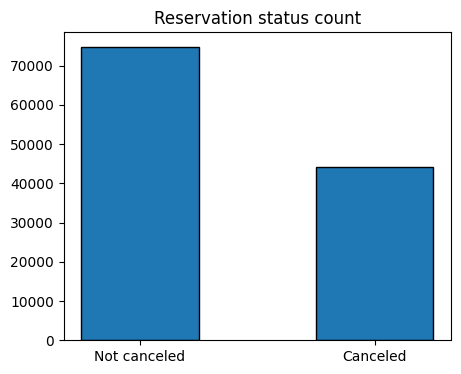

In [13]:
cancelled_perc = df['is_canceled'].value_counts(normalize = True)
print(cancelled_perc)

plt.figure(figsize = (5,4))
plt.title('Reservation status count')
plt.bar(['Not canceled','Canceled'],df['is_canceled'].value_counts(), edgecolor = 'k', width = 0.5)
plt.show()

Text(0, 0.5, 'number of reservations')

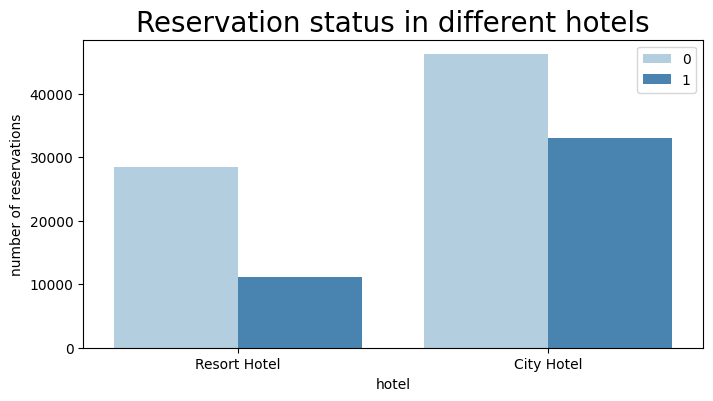

In [14]:
plt.figure(figsize = (8,4))
ax1= sns.countplot(x = 'hotel', hue = 'is_canceled', data = df, palette = 'Blues')
legend_labels,_ = ax1. get_legend_handles_labels()
ax1.legend(bbox_to_anchor=(1,1))
plt.title('Reservation status in different hotels', size = 20)
plt.xlabel('hotel')
plt.ylabel('number of reservations')

In [15]:
resort_hotel = df[df['hotel'] == 'Resort Hotel']
resort_hotel['is_canceled'].value_counts(normalize = True)

is_canceled
0    0.72025
1    0.27975
Name: proportion, dtype: float64

In [16]:
city_hotel = df[df['hotel'] == 'City Hotel']
city_hotel['is_canceled'].value_counts(normalize = True)

is_canceled
0    0.582918
1    0.417082
Name: proportion, dtype: float64

In [17]:
resort_hotel = resort_hotel.groupby('reservation_status_date')[['adr']].mean()
city_hotel = city_hotel.groupby('reservation_status_date')[['adr']].mean()

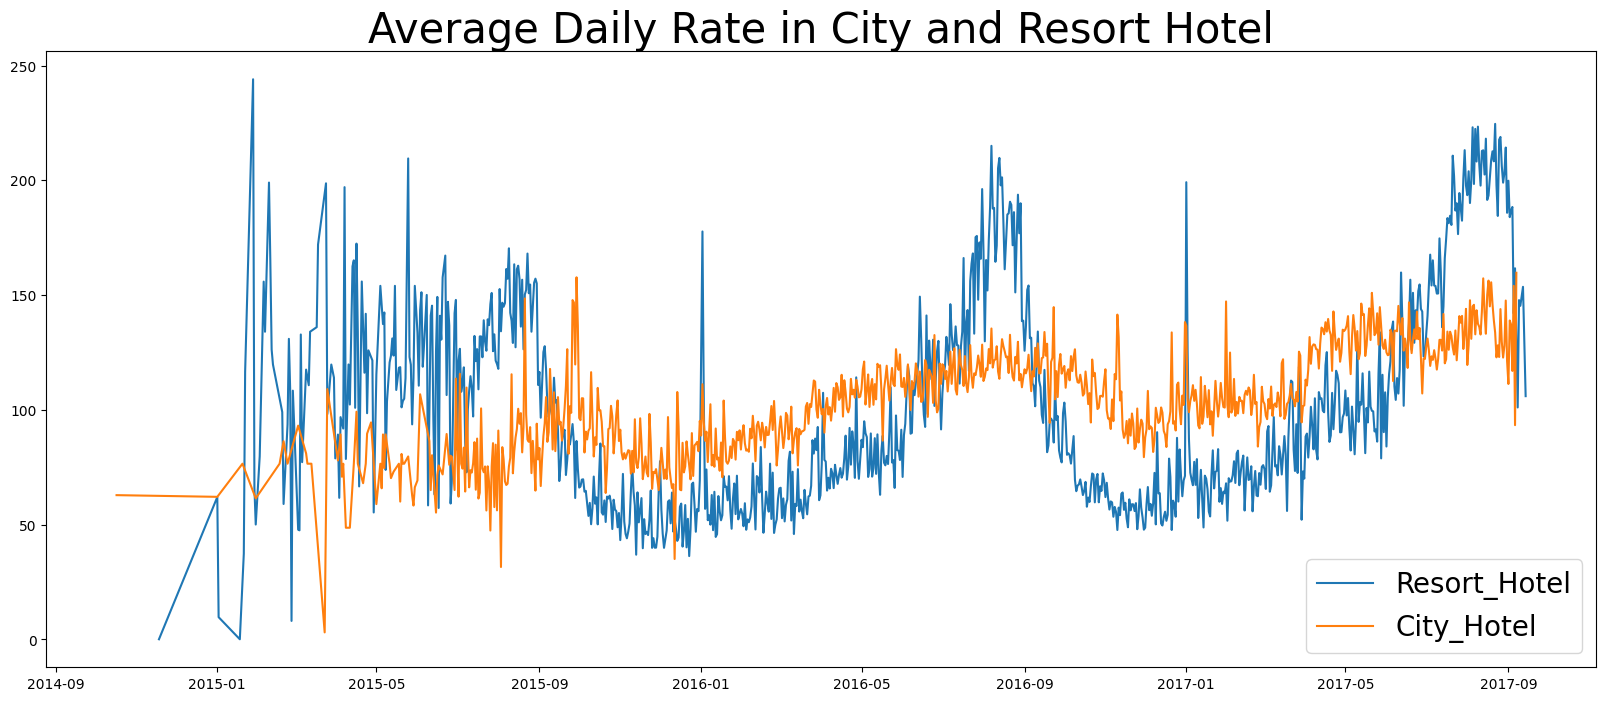

In [18]:
plt.figure(figsize = (20,8))
plt.title('Average Daily Rate in City and Resort Hotel', fontsize = 30)
plt.plot(resort_hotel.index, resort_hotel['adr'], label = 'Resort_Hotel')
plt.plot(city_hotel.index, city_hotel['adr'], label = 'City_Hotel')
plt.legend(fontsize = 20)
plt.show()


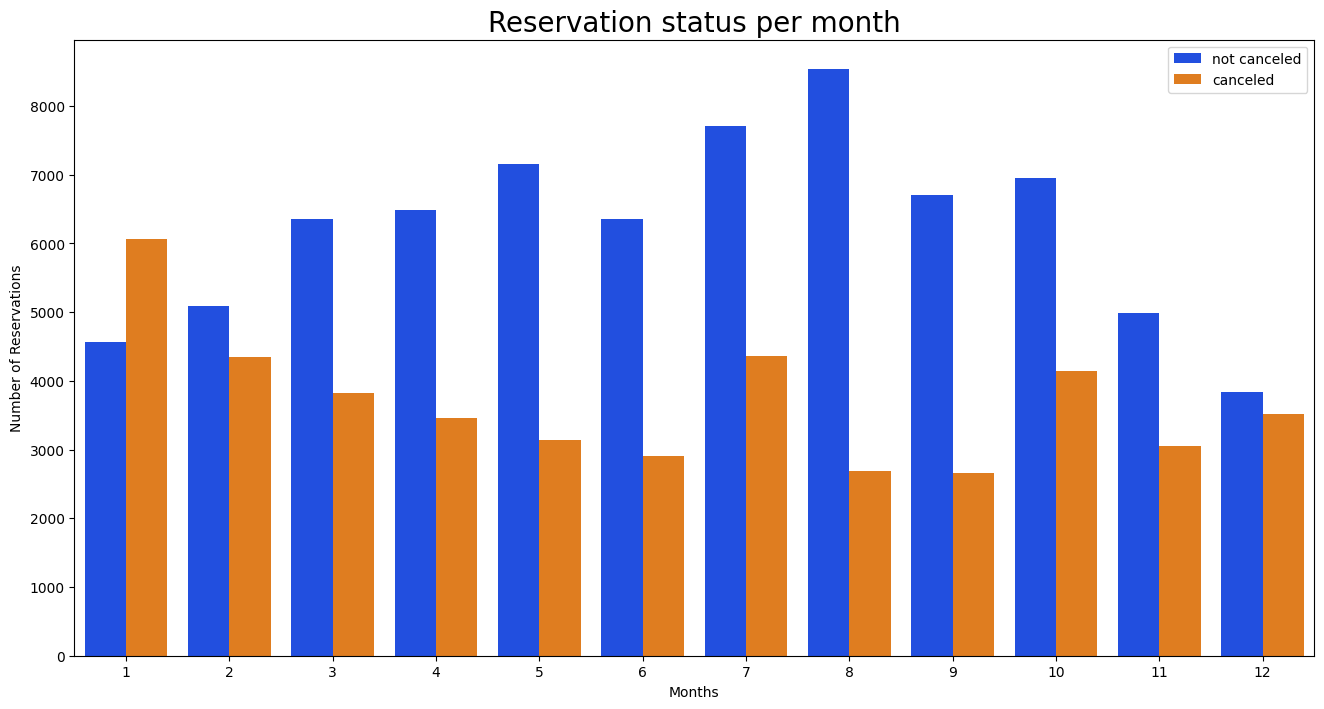

In [19]:
df ['month'] = df['reservation_status_date'].dt.month
plt.figure(figsize = (16,8))
ax1 = sns.countplot(x = 'month', hue = 'is_canceled', data = df, palette = 'bright')
legend_labels,_ = ax1. get_legend_handles_labels()
ax1.legend(bbox_to_anchor=(1,1))
plt.title('Reservation status per month', size = 20)
plt.xlabel('Months')
plt.ylabel('Number of Reservations')
plt.legend(['not canceled', 'canceled'])
plt.show()

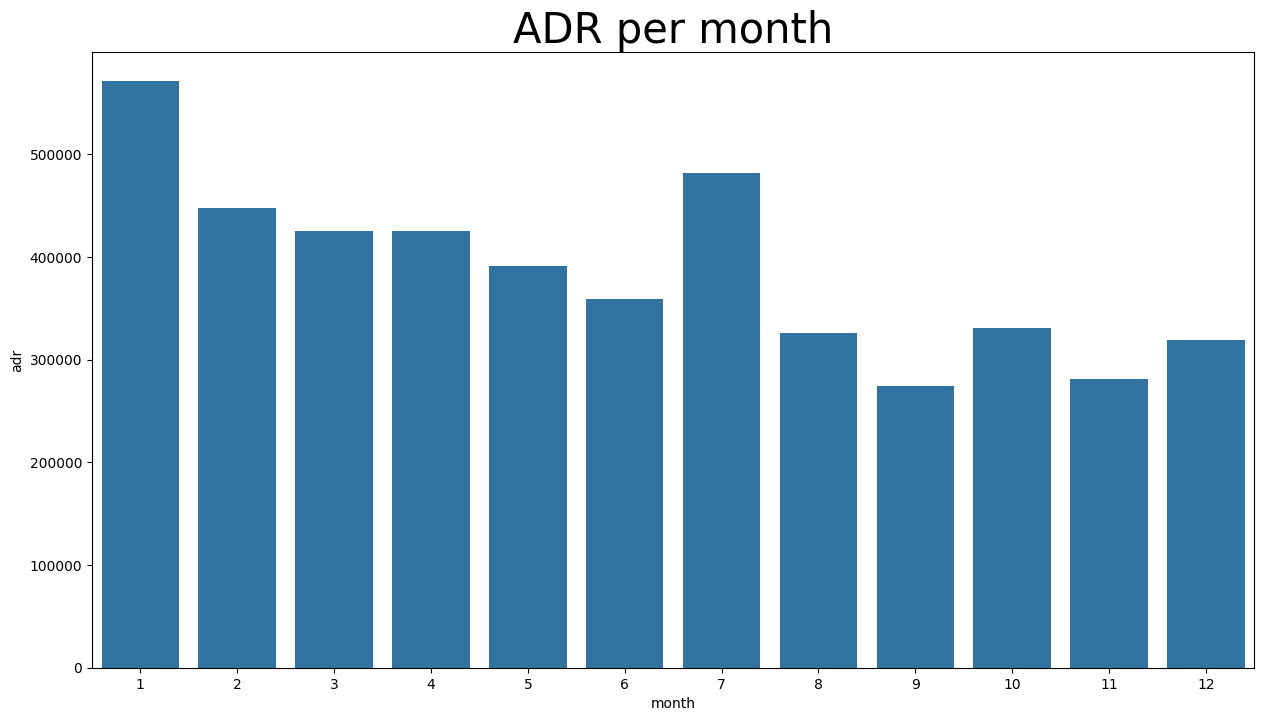

In [26]:
plt.figure(figsize = (15,8))
plt.title('ADR per month', fontsize = 30)
data = df[df['is_canceled'] == 1] .groupby ('month')[['adr']].sum().reset_index()
sns.barplot(x='month',y='adr',data=data)
plt.show()

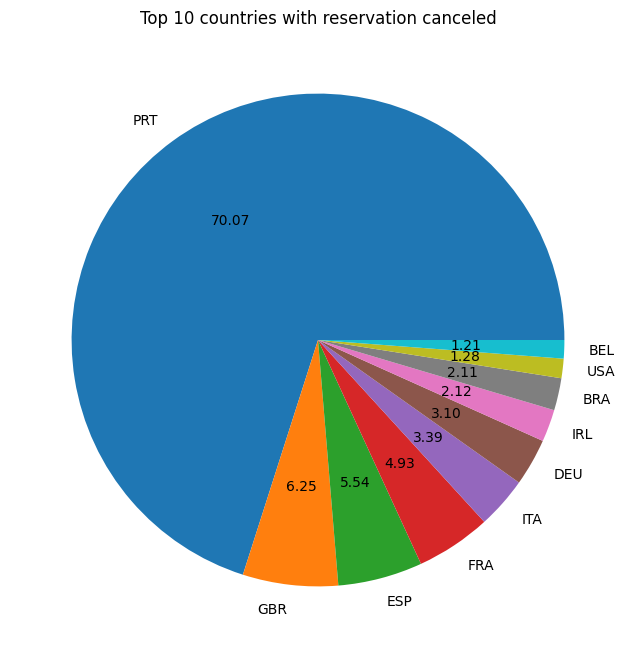

In [30]:
canceled_data = df[df['is_canceled'] ==1]
top_10_country = canceled_data ['country'].value_counts()[:10]
plt.figure(figsize = (8,8))
plt.title('Top 10 countries with reservation canceled')
plt.pie(top_10_country, autopct = '%.2f', labels = top_10_country.index)
plt.show()

In [31]:
df['market_segment'].value_counts()

market_segment
Online TA        56402
Offline TA/TO    24159
Groups           19806
Direct           12448
Corporate         5111
Complementary      734
Aviation           237
Name: count, dtype: int64

In [32]:
df['market_segment'].value_counts(normalize = True)

market_segment
Online TA        0.474377
Offline TA/TO    0.203193
Groups           0.166581
Direct           0.104696
Corporate        0.042987
Complementary    0.006173
Aviation         0.001993
Name: proportion, dtype: float64

In [34]:
canceled_data['market_segment'].value_counts(normalize = True)

market_segment
Online TA        0.469696
Groups           0.273985
Offline TA/TO    0.187466
Direct           0.043486
Corporate        0.022151
Complementary    0.002038
Aviation         0.001178
Name: proportion, dtype: float64

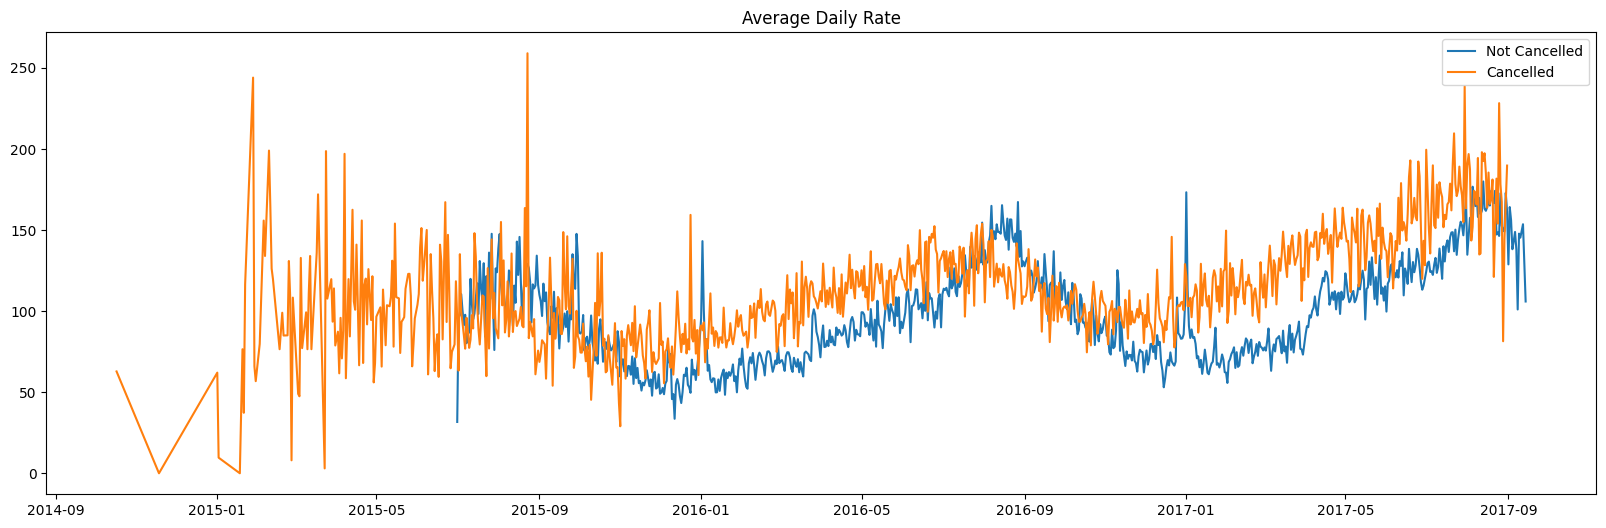

In [35]:
# Function to calculate average ADR by date
def calculate_avg_adr(data):
    return (data.groupby('reservation_status_date')['adr']
            .mean()
            .reset_index()
            .sort_values('reservation_status_date'))

# Separate data
cancelled_data = calculate_avg_adr(df[df['is_canceled'] == 1])
not_cancelled_data = calculate_avg_adr(df[df['is_canceled'] == 0])

# Plot the results
plt.figure(figsize=(20, 6))
plt.title('Average Daily Rate')

plt.plot(not_cancelled_data['reservation_status_date'],
         not_cancelled_data['adr'],
         label='Not Cancelled')

plt.plot(cancelled_data['reservation_status_date'],
         cancelled_data['adr'],
         label='Cancelled')

plt.legend()
plt.show()

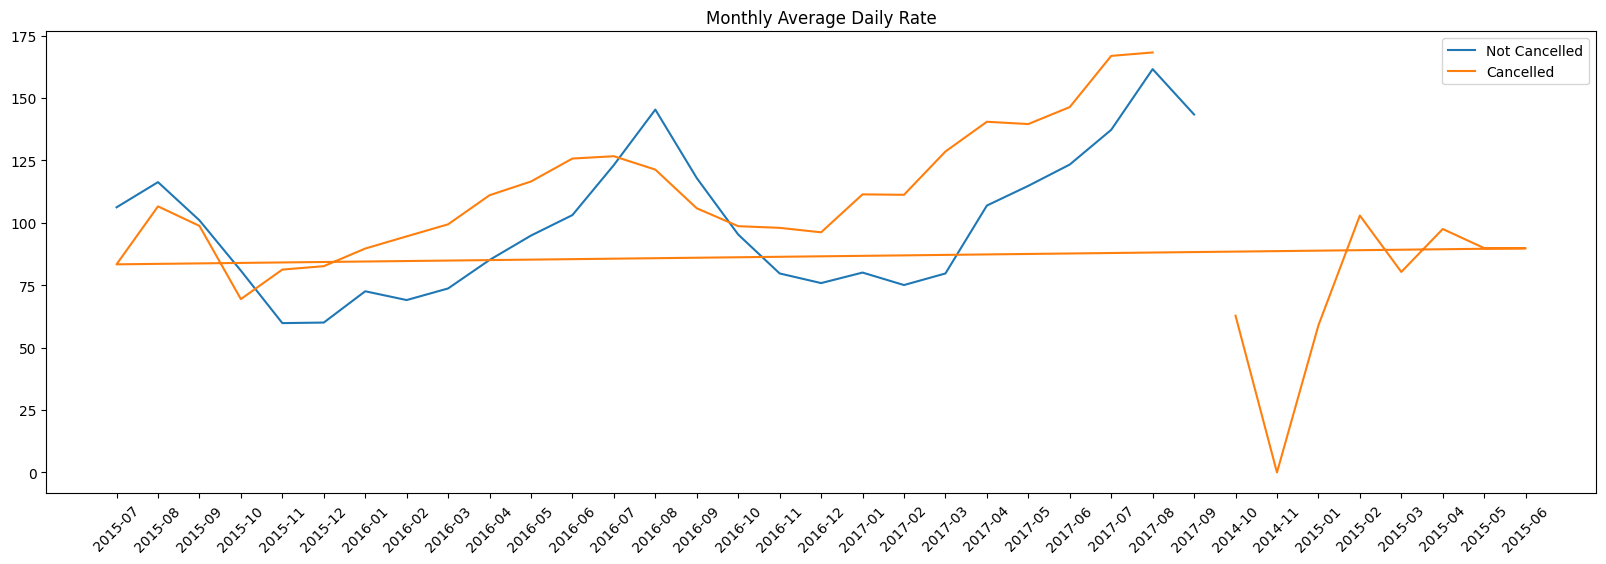

In [36]:
# Convert to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Create month column
df['month'] = df['reservation_status_date'].dt.to_period('M')

# Group by month
cancelled_data = df[df['is_canceled'] == 1].groupby('month')['adr'].mean().reset_index()
not_cancelled_data = df[df['is_canceled'] == 0].groupby('month')['adr'].mean().reset_index()

# Convert period to string (for plotting)
cancelled_data['month'] = cancelled_data['month'].astype(str)
not_cancelled_data['month'] = not_cancelled_data['month'].astype(str)

# Plot
plt.figure(figsize=(20,6))
plt.plot(not_cancelled_data['month'], not_cancelled_data['adr'], label='Not Cancelled')
plt.plot(cancelled_data['month'], cancelled_data['adr'], label='Cancelled')

plt.title('Monthly Average Daily Rate')
plt.xticks(rotation=45)
plt.legend()
plt.show()